
# CIS143-6 Applications of AI
# WEEK 1 - SETUP AND DATA UNDERSTANDING

### Brain Tumour MRI Classification - Student Lab Template
### Platform: Google Colab
### Framework: TensorFlow / Keras



#Tumor Types in the Brain MRI Dataset

This dataset contains MRI scans of the brain categorized into four classes based on the presence and type of tumor. MRI (Magnetic Resonance Imaging) is commonly used in medical diagnostics because it provides detailed images of brain structures and abnormalities.

##Glioma
Gliomas are tumors that originate from glial cells in the brain. They often appear as irregular or diffuse bright regions within brain tissue and can vary significantly in size and shape.

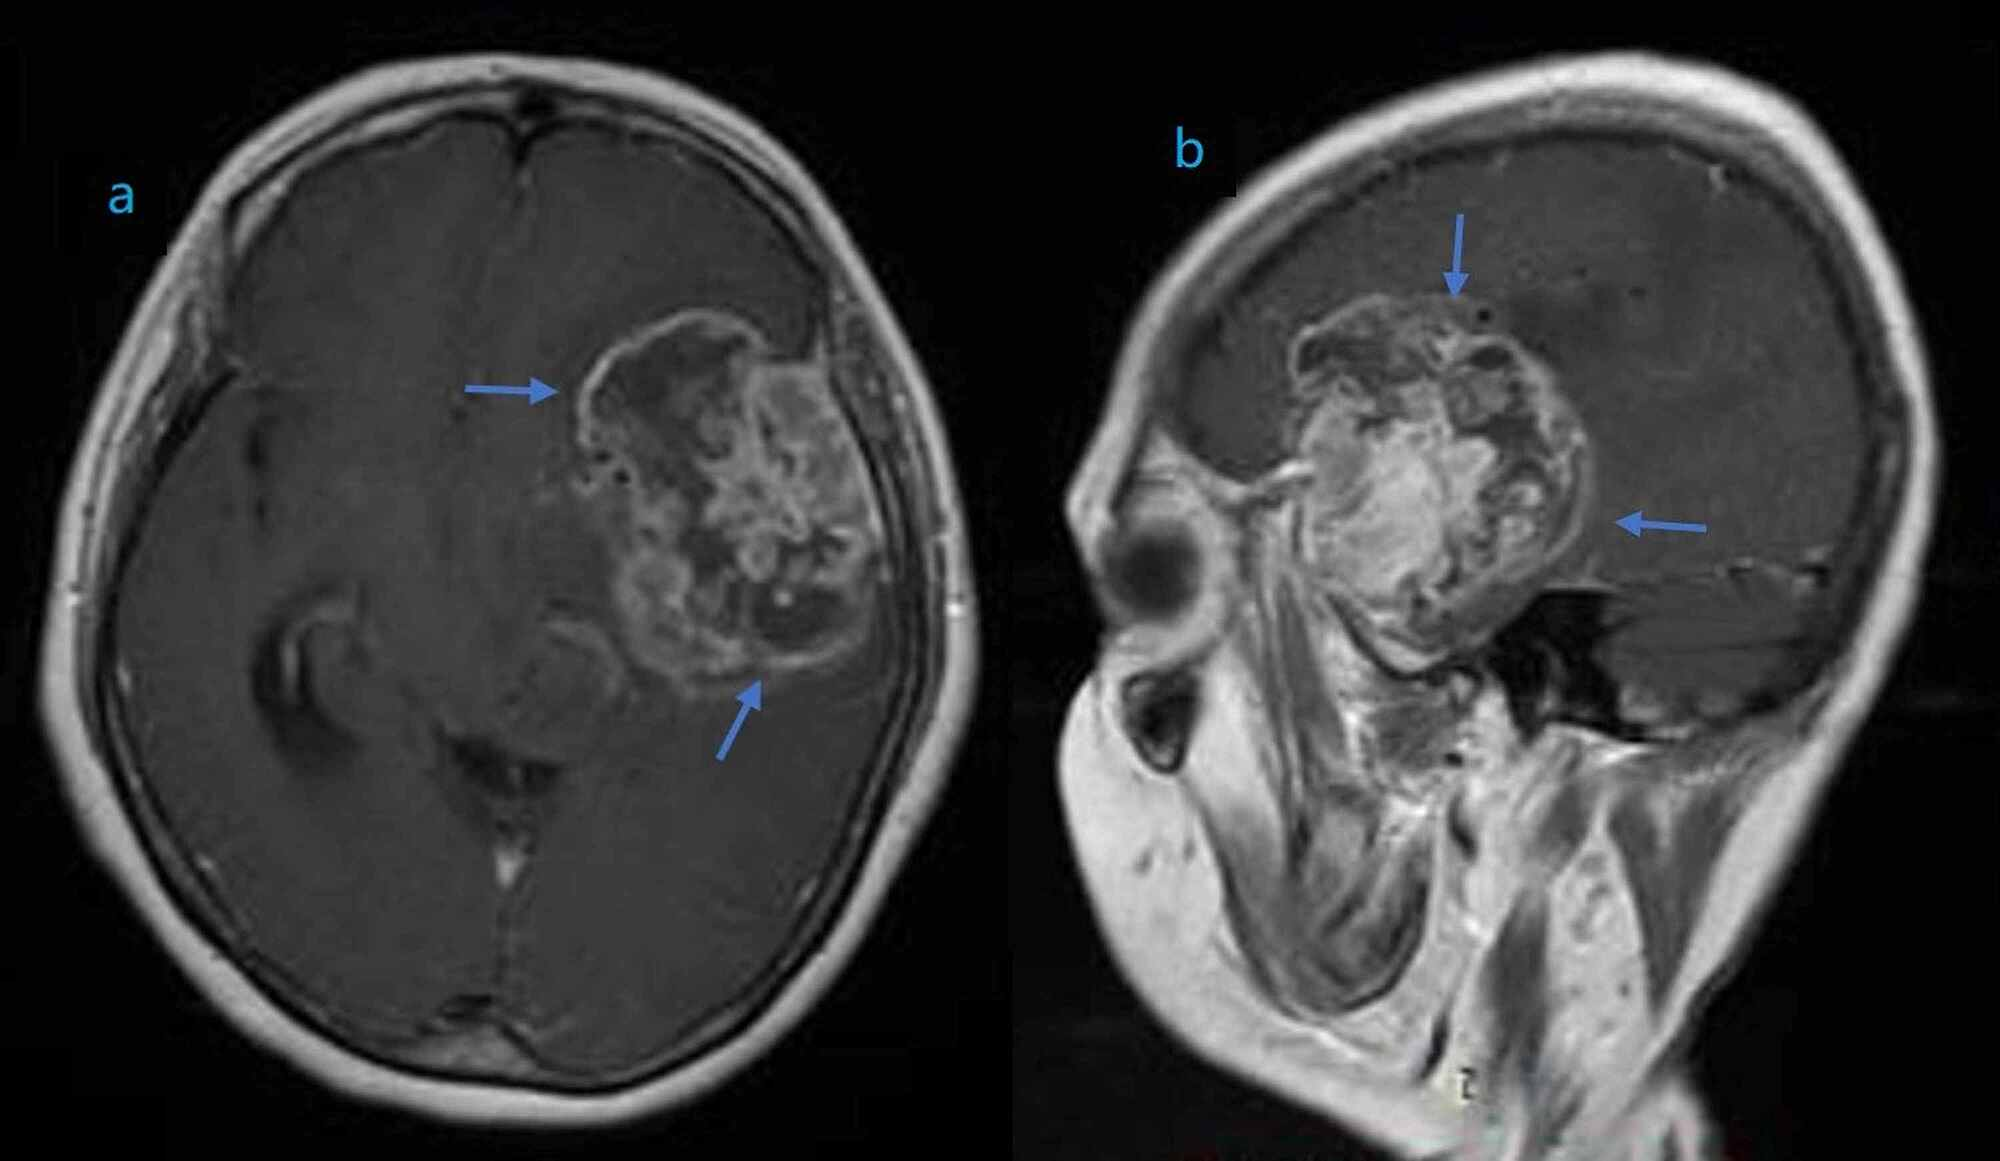

##Meningioma
Meningiomas develop in the meninges, the protective layers surrounding the brain and spinal cord. In MRI images, they typically appear as well-defined masses located near the outer boundary of the brain.

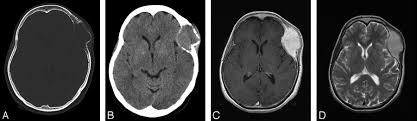

##Pituitary Tumor
Pituitary tumors occur in the pituitary gland, a small gland located at the base of the brain. These tumors usually appear as small abnormal regions near the center of the brain in MRI scans.
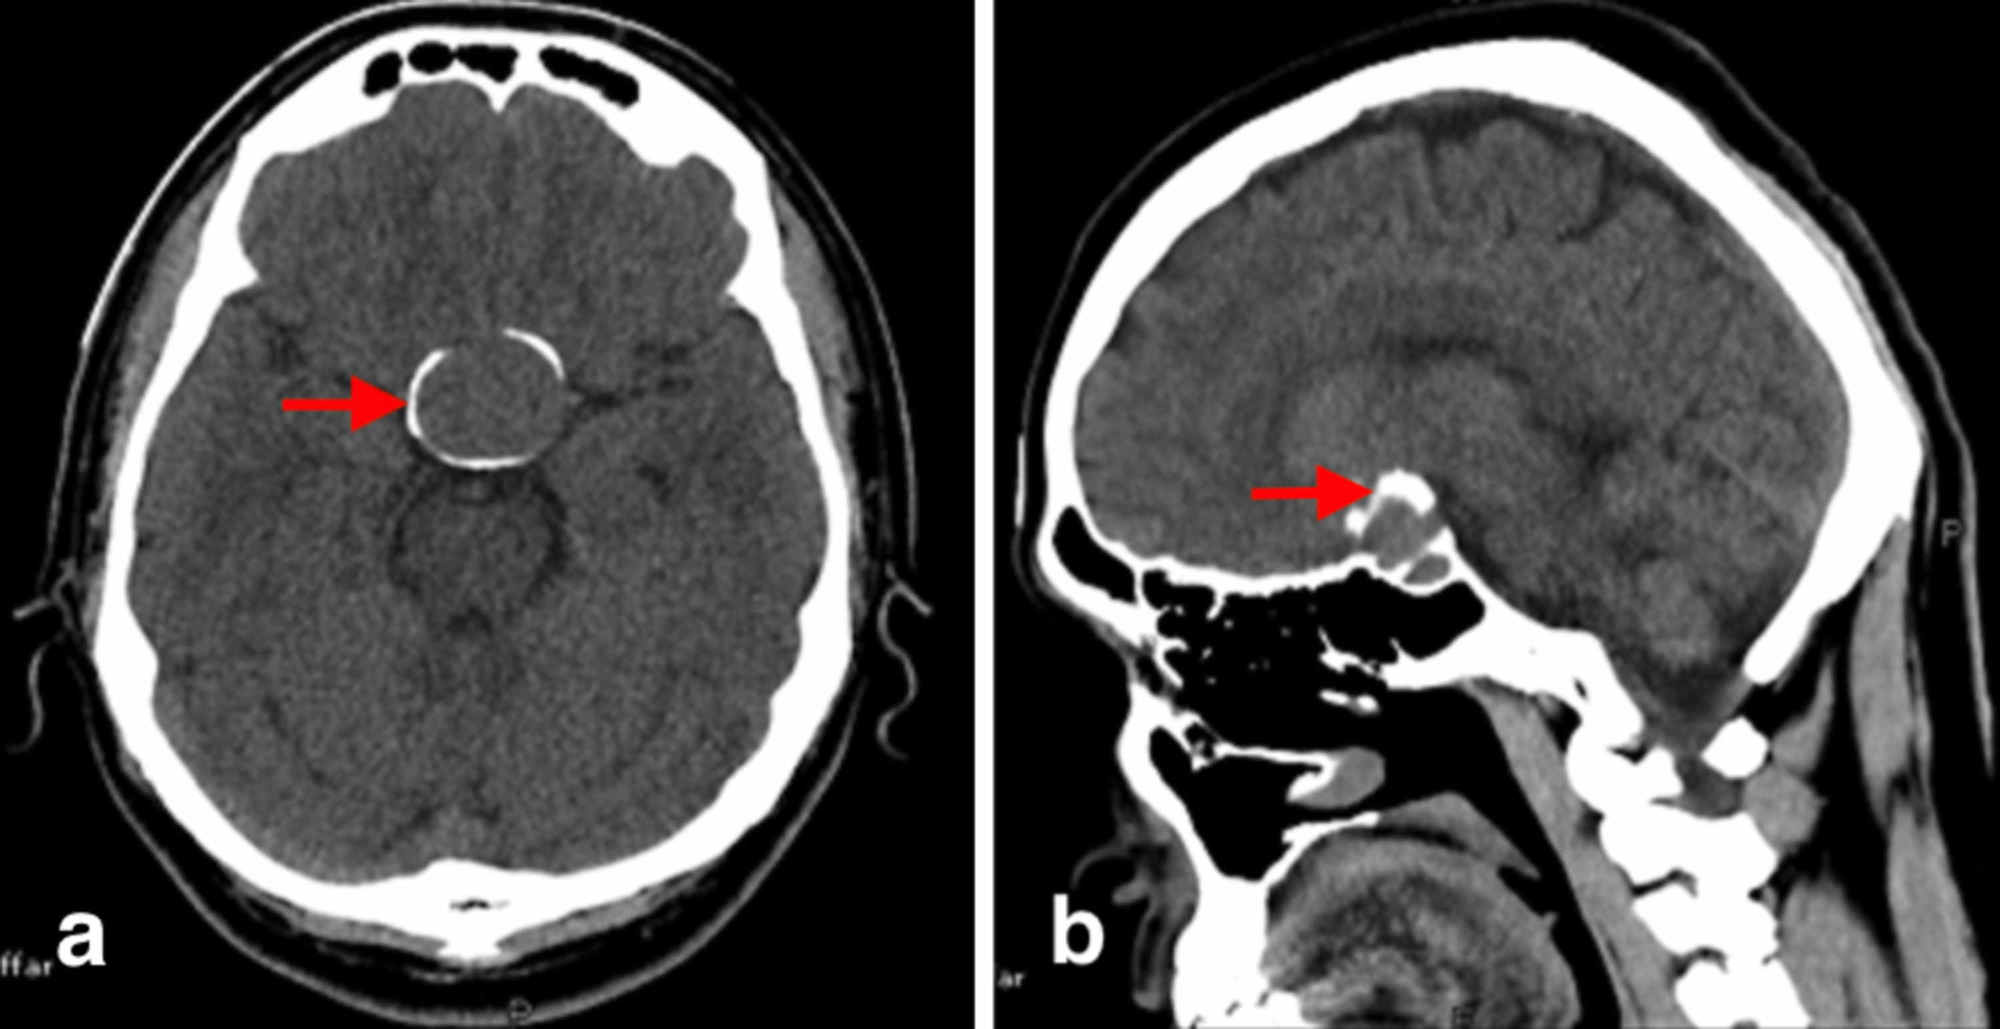
##No Tumor (Normal)
This category contains MRI images of healthy brains where no tumor is present. The brain structure appears symmetrical without abnormal masses or bright regions.

Understanding these visual differences helps in developing AI models that can automatically detect and classify tumors from MRI images.

In [19]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------
# Imports
# ---------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

# ---------------------------
# Dataset paths
# ---------------------------
dataset_path = "/content/drive/MyDrive/MRI_Data"
train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")

print("Training path:", train_dir)
print("Testing path:", test_dir)

# ---------------------------
# Check folder structure
# ---------------------------
print("\nTop-level folders:")
for folder in os.listdir(dataset_path):
    print("-", folder)

print("\nTraining classes and image counts:")
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

print("\nTesting classes and image counts:")
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
Training path: /content/drive/MyDrive/MRI_Data/Training
Testing path: /content/drive/MyDrive/MRI_Data/Testing

Top-level folders:
- Training
- Testing

Training classes and image counts:
meningioma : 1400
notumor : 1400
pituitary : 1400
glioma : 1400

Testing classes and image counts:
glioma : 400
pituitary : 400
notumor : 400
meningioma : 400



# WEEK 1 - VISUALISING THE DATA



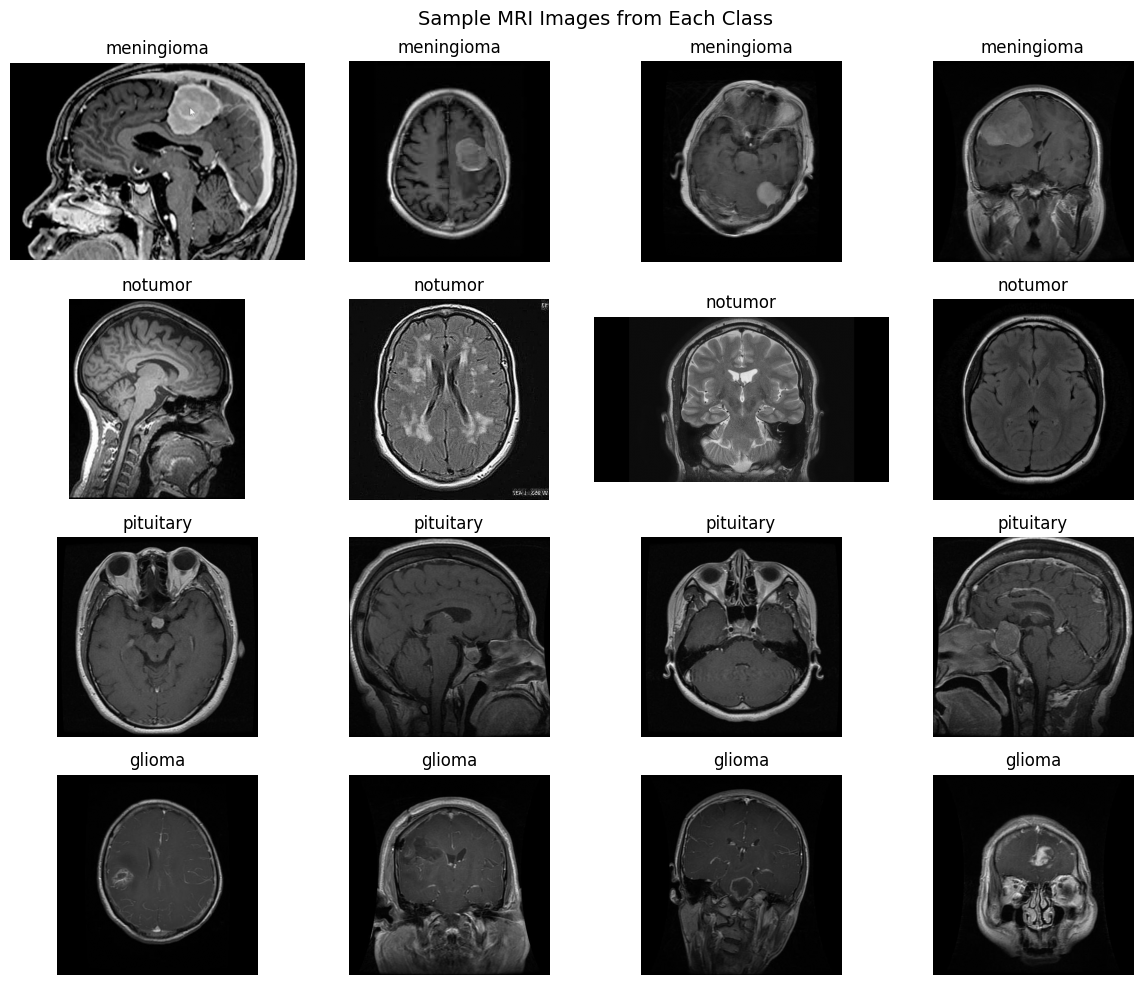

In [21]:
# ---------------------------
# Plot sample images from each class
# ---------------------------
classes = os.listdir(train_dir)
samples_per_class = 4

plt.figure(figsize=(12, 10))
plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:samples_per_class]

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path).convert("L")

        plt.subplot(len(classes), samples_per_class, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

After showing random samples, it is useful to manually show a clear example tumor from each class so students can visually understand what the tumor actually looks like before any modelling.

The simplest approach is to pick one representative image from each folder and display it.

Below is a very simple and clean code.


##Class	->Visual cue
* glioma	->irregular bright mass
* meningioma	->round tumor near brain edge
* pituitary	->tumor near pituitary gland
* notumor	->normal brain structure

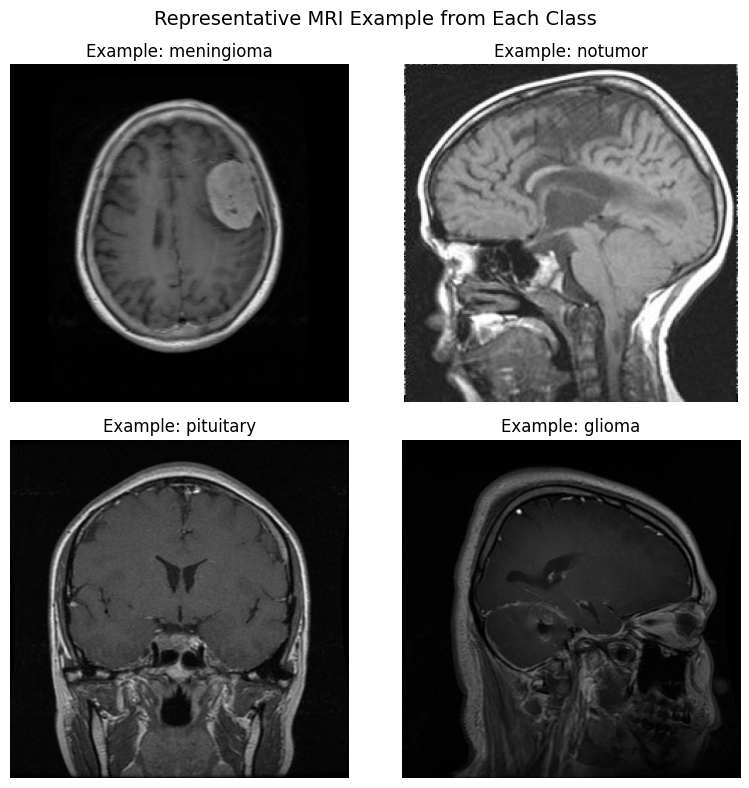

In [22]:
# ---------------------------
# Plot one representative image from each class
# ---------------------------
plt.figure(figsize=(8, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    # Pick one example image
    image_name = image_names[min(10, len(image_names)-1)]
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path).convert("L")

    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Example: {class_name}")
    plt.axis("off")

plt.suptitle("Representative MRI Example from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

#Different MRI orientations

You can see different brain views:

* Axial (top view) → most notumor images

* Coronal (front view) → many meningioma images

* Sagittal (side view) → many pituitary images

Example from your figure:

the dataset contains multiple imaging planes.

##Why this matters

For CNN models:

* orientation variation increases difficulty

* model must learn tumor patterns, not orientation

1️⃣ Class Distribution Plot

This shows how many MRI images exist per tumour type:

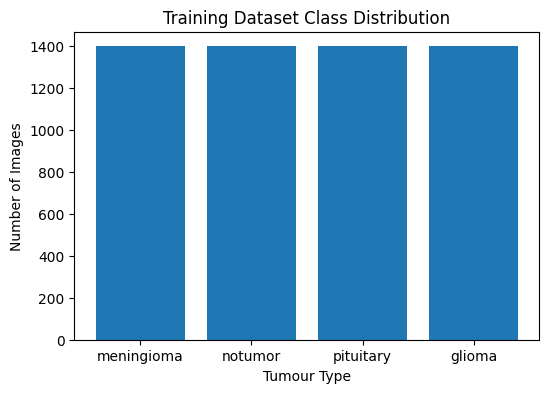

In [24]:
# ---------------------------
# Class distribution plot
# ---------------------------
class_counts = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(6, 4))
plt.bar(classes, class_counts)
plt.title("Training Dataset Class Distribution")
plt.xlabel("Tumour Type")
plt.ylabel("Number of Images")
plt.show()


#The average image per class is a very powerful visualization for students.
It shows the typical structure of each tumor type by averaging many MRI scans.

This helps students see general tumor patterns instead of individual cases.

Below is a simple and clean implementation

##What Students Will See

The result will show 4 averaged brains:

* Average glioma
* Average meningioma
* Average pituitary
* Average notumor

#Typical observations:

* notumor → normal brain symmetry

* glioma → irregular bright regions

* meningioma → localized tumor region

* pituitary → structure near center

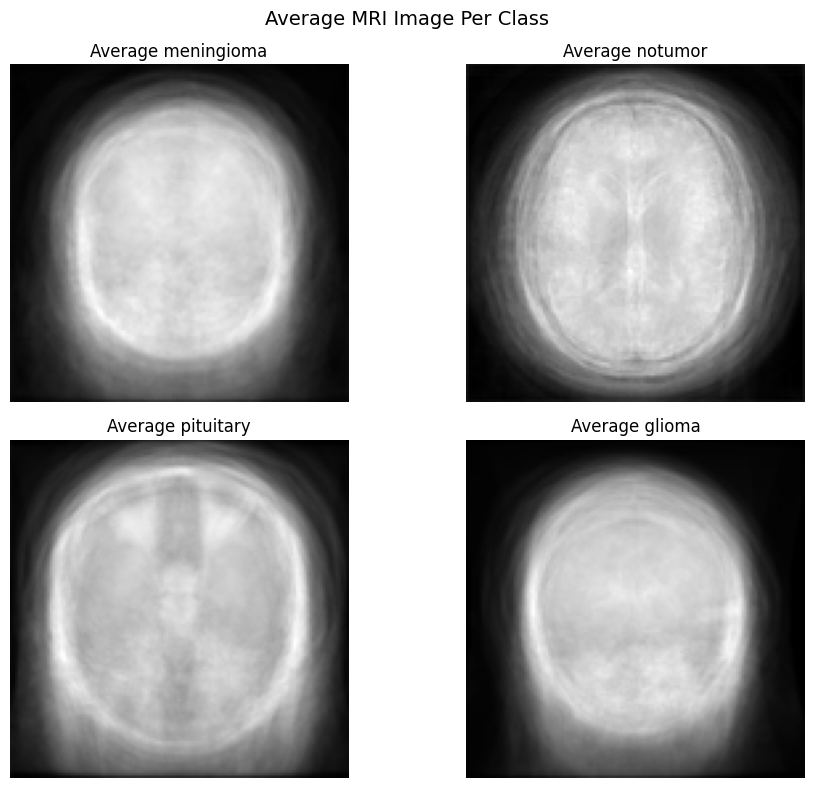

In [25]:
# ---------------------------
# Average image per class
# ---------------------------
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    image_stack = []

    for image_name in image_names[:200]:   # limit for speed
        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path).convert("L").resize((128, 128))
        img_array = np.array(img)
        image_stack.append(img_array)

    avg_image = np.mean(image_stack, axis=0)

    plt.subplot(2, 2, i + 1)
    plt.imshow(avg_image, cmap="gray")
    plt.title(f"Average {class_name}")
    plt.axis("off")

plt.suptitle("Average MRI Image Per Class", fontsize=14)
plt.tight_layout()
plt.show()

#  Image Size Distribution
This checks whether MRI images have the same resolution.

#What students learn

Real datasets rarely have uniform sizes

Why image resizing is required before CNN training

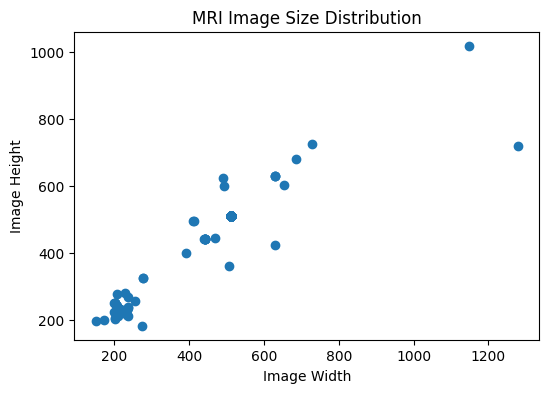

In [26]:
# ---------------------------
# Image size distribution
# ---------------------------
widths = []
heights = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:50]

    for image_name in image_names:
        img = Image.open(os.path.join(class_path, image_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6, 4))
plt.scatter(widths, heights)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("MRI Image Size Distribution")
plt.show()


# WEEK 2 - BUILD DATAFRAMES AND PREPROCESSING PIPELINE


In [27]:


# ---------------------------
# Create DataFrame for training images
# ---------------------------
train_filepaths = []
train_labels = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        train_filepaths.append(image_path)
        train_labels.append(class_name)

train_df = pd.DataFrame({
    "File Path": train_filepaths,
    "Label": train_labels
})

print("\nTraining DataFrame:")
display(train_df.head())
print("Total training images:", len(train_df))

# ---------------------------
# Create DataFrame for testing images
# ---------------------------
test_filepaths = []
test_labels = []

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    image_names = os.listdir(class_path)

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        test_filepaths.append(image_path)
        test_labels.append(class_name)

test_all_df = pd.DataFrame({
    "File Path": test_filepaths,
    "Label": test_labels
})

print("\nTesting DataFrame:")
display(test_all_df.head())
print("Total testing images:", len(test_all_df))

# ---------------------------
# Split testing folder into validation and final test
# ---------------------------
valid_df, test_df = train_test_split(
    test_all_df,
    test_size=0.5,
    random_state=42,
    stratify=test_all_df["Label"]
)

print("\nValidation images:", len(valid_df))
print("Final test images:", len(test_df))

# ---------------------------
# ImageDataGenerator with rescaling
# ---------------------------
image_size = (224, 224)
train_batch_size = 16
test_batch_size = 8

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

valid_gen = test_datagen.flow_from_dataframe(
    valid_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

print("\nClass indices:", train_gen.class_indices)




Training DataFrame:


,File Path,Label
0,/content/drive/MyDrive/MRI_Data/Training/menin...,meningioma
1,/content/drive/MyDrive/MRI_Data/Training/menin...,meningioma
2,/content/drive/MyDrive/MRI_Data/Training/menin...,meningioma
3,/content/drive/MyDrive/MRI_Data/Training/menin...,meningioma
4,/content/drive/MyDrive/MRI_Data/Training/menin...,meningioma


Total training images: 5600

Testing DataFrame:


,File Path,Label
0,/content/drive/MyDrive/MRI_Data/Testing/glioma...,glioma
1,/content/drive/MyDrive/MRI_Data/Testing/glioma...,glioma
2,/content/drive/MyDrive/MRI_Data/Testing/glioma...,glioma
3,/content/drive/MyDrive/MRI_Data/Testing/glioma...,glioma
4,/content/drive/MyDrive/MRI_Data/Testing/glioma...,glioma


Total testing images: 1600

Validation images: 800
Final test images: 800
Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# WEEK 3 - BASELINE CNN MODEL

In [29]:
# ---------------------------
# Build baseline CNN
# ---------------------------
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(16, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

model.summary()

# ---------------------------
# Compile model
# ---------------------------
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ---------------------------
# Train baseline model
# Start with fewer epochs for lab practice
# ---------------------------
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       692,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 719,380 (2.74 MB)

 Trainable params: 719,380 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 52s 135ms/step - accuracy: 0.5827 - loss: 0.9463 - val_accuracy: 0.6913 - val_loss: 1.0652
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.8224 - loss: 0.4565 - val_accuracy: 0.7575 - val_loss: 0.7999
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.8641 - loss: 0.3440 - val_accuracy: 0.7850 - val_loss: 0.8018
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9054 - loss: 0.2608 - val_accuracy: 0.7812 - val_loss: 0.8523
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9337 - loss: 0.1878 - val_accuracy: 0.8400 - val_loss: 0.7396


# WEEK 4 - EVALUATION AND TRAINING CURVES



Training set evaluation:
350/350 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9494 - loss: 0.1464

Validation set evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8409 - loss: 0.7482

Test set evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8318 - loss: 0.6949


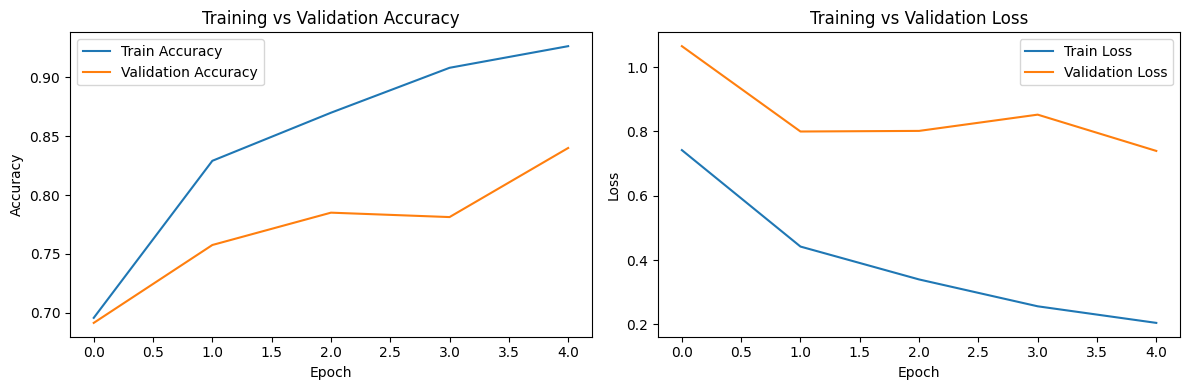

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.68      0.77       200
  meningioma       0.79      0.83      0.81       200
     notumor       0.84      0.98      0.91       200
   pituitary       0.95      0.95      0.95       200

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



<Figure size 600x600 with 0 Axes>

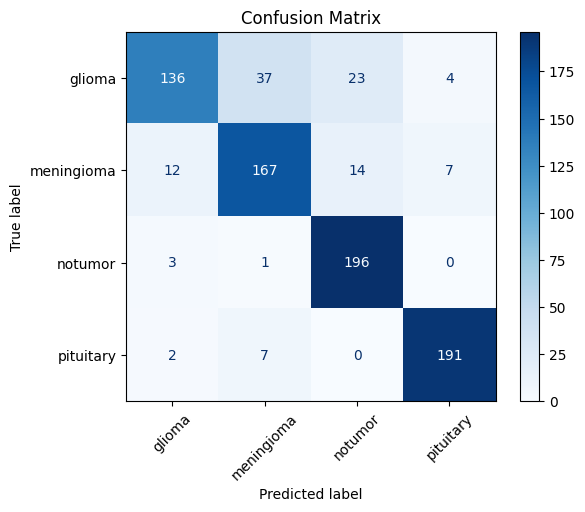

In [30]:
# ---------------------------
# Evaluate on training, validation, and test sets
# ---------------------------
print("\nTraining set evaluation:")
train_results = model.evaluate(train_gen, verbose=1)

print("\nValidation set evaluation:")
valid_results = model.evaluate(valid_gen, verbose=1)

print("\nTest set evaluation:")
test_results = model.evaluate(test_gen, verbose=1)

# ---------------------------
# Plot training history
# ---------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------
# Predictions on test set
# ---------------------------
pred_probs = model.predict(test_gen)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------
# Classification report
# ---------------------------
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# ---------------------------
# Confusion matrix
# ---------------------------
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# WEEK 5 - MODEL IMPROVEMENT AND EXPERIMENTS


Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.5668 - loss: 0.9740 - val_accuracy: 0.6675 - val_loss: 1.0402
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.8005 - loss: 0.5325 - val_accuracy: 0.7487 - val_loss: 0.8825
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.8585 - loss: 0.3821 - val_accuracy: 0.7800 - val_loss: 0.8511
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.8830 - loss: 0.3078 - val_accuracy: 0.7850 - val_loss: 0.7288
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.9053 - loss: 0.2676 - val_accuracy: 0.8363 - val_loss: 0.7714

Improved model test evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8458 - loss: 0.7134


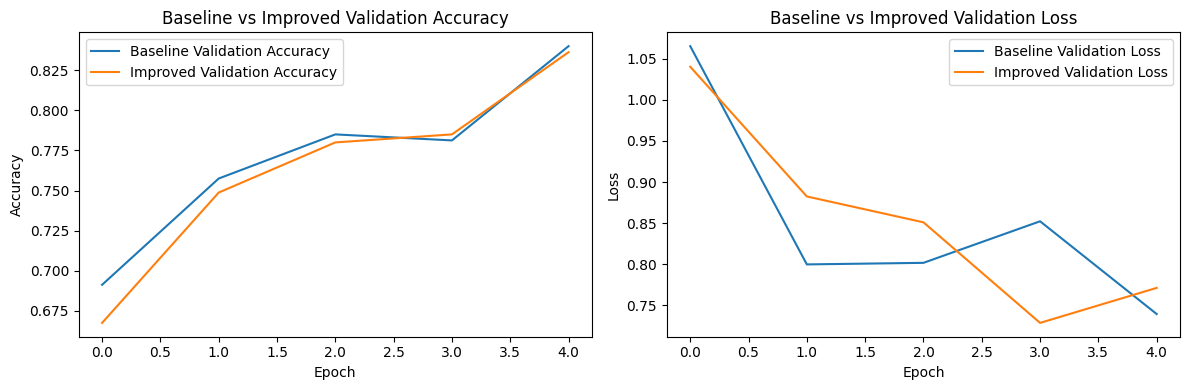

In [31]:
# Students can modify:
# - learning rate
# - filters
# - extra dropout
# - number of dense units
# Then retrain and compare with baseline

improved_model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])

improved_model.compile(
    optimizer=Adamax(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

improved_history = improved_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

print("\nImproved model test evaluation:")
improved_model.evaluate(test_gen, verbose=1)

# ---------------------------
# Compare training curves
# ---------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["val_accuracy"], label="Baseline Validation Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Improved Validation Accuracy")
plt.title("Baseline vs Improved Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="Baseline Validation Loss")
plt.plot(improved_history.history["val_loss"], label="Improved Validation Loss")
plt.title("Baseline vs Improved Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# WEEK 6 - DATA AUGMENTATION


Found 5600 validated image filenames belonging to 4 classes.
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 109s 299ms/step - accuracy: 0.4597 - loss: 1.1599 - val_accuracy: 0.6825 - val_loss: 0.8808
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.7164 - loss: 0.6957 - val_accuracy: 0.6612 - val_loss: 0.9651
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 297ms/step - accuracy: 0.7423 - loss: 0.6170 - val_accuracy: 0.6938 - val_loss: 1.0948
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 297ms/step - accuracy: 0.7872 - loss: 0.5432 - val_accuracy: 0.7375 - val_loss: 0.8812
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 105s 299ms/step - accuracy: 0.8041 - loss: 0.5152 - val_accuracy: 0.7688 - val_loss: 0.8172

Augmented model test evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7512 - loss: 0.8244


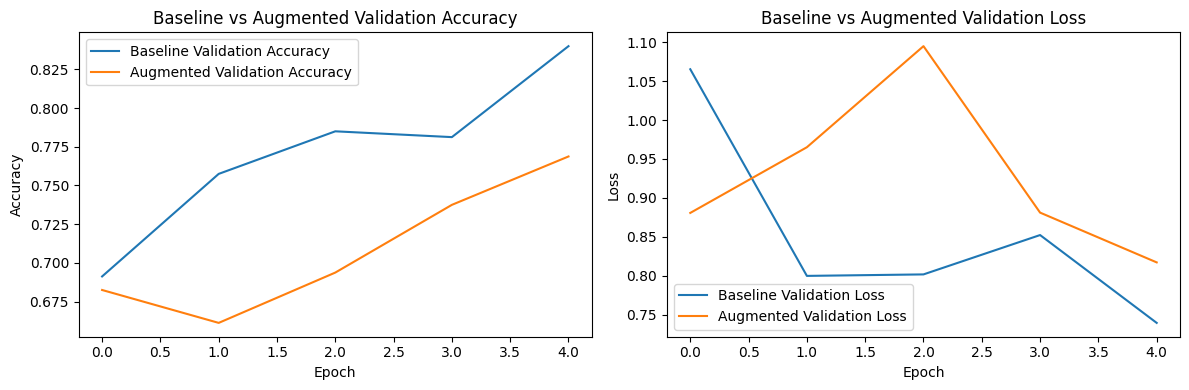


End of template.


In [32]:
# ---------------------------
# ImageDataGenerator with augmentation
# ---------------------------
aug_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

aug_train_gen = aug_train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

# ---------------------------
# Train augmented model
# ---------------------------
aug_model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(16, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

aug_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

aug_history = aug_model.fit(
    aug_train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

print("\nAugmented model test evaluation:")
aug_model.evaluate(test_gen, verbose=1)

# ---------------------------
# Compare baseline vs augmentation
# ---------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["val_accuracy"], label="Baseline Validation Accuracy")
plt.plot(aug_history.history["val_accuracy"], label="Augmented Validation Accuracy")
plt.title("Baseline vs Augmented Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="Baseline Validation Loss")
plt.plot(aug_history.history["val_loss"], label="Augmented Validation Loss")
plt.title("Baseline vs Augmented Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL - SAVE MODEL
# ============================================================

# Uncomment if you want to save a model
# model.save("/content/drive/MyDrive/brain_tumor_baseline_model.h5")
# improved_model.save("/content/drive/MyDrive/brain_tumor_improved_model.h5")
# aug_model.save("/content/drive/MyDrive/brain_tumor_augmented_model.h5")

print("\nEnd of template.")

##End of code -------------------------------------------------------------------------